<a href="https://colab.research.google.com/github/nishnarudkar/Interpretable-Machine-Learning-System-for-Parkinson-s-Disease-Detection-from-Speech-Biomarkers/blob/main/notebooks/Parkinsons_Detection_MLOPS_Project_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

In [75]:
df = pd.read_csv("/content/drive/MyDrive/Parkinson's Dataset for Mlops Project/pd_speech_features.csv",header=1)

In [76]:
df.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [77]:
df.shape

(756, 755)

In [78]:
df = df.drop("id", axis=1)

In [79]:
df.shape

(756, 754)

In [80]:
df["class"].value_counts()

,count
class,
1,564
0,192


In [81]:
X = df.drop("class", axis=1)
y = df["class"]

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [83]:
print(X_train.shape)
print(X_test.shape)

(604, 753)
(152, 753)


In [84]:
# Use SMOTE only to help selector learn minority features
smote_fs = SMOTE(random_state=42)
X_train_fs, y_train_fs = smote_fs.fit_resample(X_train, y_train)

In [85]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
selector = SelectFromModel(rf_selector, max_features=100)

In [86]:
selector.fit(X_train_fs, y_train_fs)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

In [87]:
selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices]

In [88]:
#Scaling

scaler = StandardScaler()
X_train_sel_scaled = scaler.fit_transform(X_train_sel)
X_test_sel_scaled = scaler.transform(X_test_sel)

In [89]:
# SMOTE for Training

smote = SMOTE(random_state=42)

X_train_sel_smote, y_train_smote = smote.fit_resample(X_train_sel, y_train)
X_train_scaled_smote, _ = smote.fit_resample(X_train_sel_scaled, y_train)

### Models


#### Linear Regression

In [90]:
# Initialize the list if it doesn't exist yet!
if 'model_results' not in locals():
    model_results = []

print("--- Training Logistic Regression ---")
# Increased max_iter to ensure the solver converges on the complex SMOTE data
lr = LogisticRegression(max_iter=1000, random_state=42)

# Fit on SCALED data
lr.fit(X_train_scaled_smote, y_train_smote)

# Predict on SCALED test data
y_pred_lr = lr.predict(X_test_sel_scaled)
y_prob_lr = lr.predict_proba(X_test_sel_scaled)[:, 1]

# Calculate metrics
macro_f1_lr = f1_score(y_test, y_pred_lr, average="macro")
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

# Log results
model_results.append({
    "Model": "Logistic Regression",
    "Macro F1": macro_f1_lr,
    "ROC AUC": roc_auc_lr
})

print(classification_report(y_test, y_pred_lr))

--- Training Logistic Regression ---
              precision    recall  f1-score   support

           0       0.64      0.72      0.67        39
           1       0.90      0.86      0.88       113

    accuracy                           0.82       152
   macro avg       0.77      0.79      0.78       152
weighted avg       0.83      0.82      0.83       152



#### Random Forest

In [91]:
from sklearn.ensemble import RandomForestClassifier

print("--- Training Random Forest ---")
rf = RandomForestClassifier(n_estimators=300, random_state=42)

# Fit on UNSCALED data
rf.fit(X_train_sel_smote, y_train_smote)
y_pred_rf = rf.predict(X_test_sel)
y_prob_rf = rf.predict_proba(X_test_sel)[:, 1]

macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

model_results.append({"Model": "Random Forest", "Macro F1": macro_f1_rf, "ROC AUC": roc_auc_rf})
print(classification_report(y_test, y_pred_rf))

--- Training Random Forest ---
              precision    recall  f1-score   support

           0       0.74      0.74      0.74        39
           1       0.91      0.91      0.91       113

    accuracy                           0.87       152
   macro avg       0.83      0.83      0.83       152
weighted avg       0.87      0.87      0.87       152



#### Support Vector Machine (SVM)

In [92]:
from sklearn.svm import SVC

print("--- Training SVM ---")
svm = SVC(probability=True, random_state=42)

# Fit on SCALED data
svm.fit(X_train_scaled_smote, y_train_smote)
y_pred_svm = svm.predict(X_test_sel_scaled)
y_prob_svm = svm.predict_proba(X_test_sel_scaled)[:, 1]

macro_f1_svm = f1_score(y_test, y_pred_svm, average="macro")
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

model_results.append({"Model": "SVM", "Macro F1": macro_f1_svm, "ROC AUC": roc_auc_svm})
print(classification_report(y_test, y_pred_svm))

--- Training SVM ---
              precision    recall  f1-score   support

           0       0.72      0.79      0.76        39
           1       0.93      0.89      0.91       113

    accuracy                           0.87       152
   macro avg       0.82      0.84      0.83       152
weighted avg       0.87      0.87      0.87       152



#### XGBoost

In [93]:
from xgboost import XGBClassifier

print("--- Training XGBoost ---")
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, eval_metric="logloss", random_state=42)

# Fit on UNSCALED data
xgb.fit(X_train_sel_smote, y_train_smote)
y_pred_xgb = xgb.predict(X_test_sel)
y_prob_xgb = xgb.predict_proba(X_test_sel)[:, 1]

macro_f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

model_results.append({"Model": "XGBoost", "Macro F1": macro_f1_xgb, "ROC AUC": roc_auc_xgb})
print(classification_report(y_test, y_pred_xgb))

--- Training XGBoost ---
              precision    recall  f1-score   support

           0       0.76      0.79      0.78        39
           1       0.93      0.91      0.92       113

    accuracy                           0.88       152
   macro avg       0.84      0.85      0.85       152
weighted avg       0.88      0.88      0.88       152



#### KNN

In [94]:
from sklearn.neighbors import KNeighborsClassifier

print("--- Training KNN ---")
knn = KNeighborsClassifier(n_neighbors=5)

# Fit on SCALED data
knn.fit(X_train_scaled_smote, y_train_smote)
y_pred_knn = knn.predict(X_test_sel_scaled)
y_prob_knn = knn.predict_proba(X_test_sel_scaled)[:, 1]

macro_f1_knn = f1_score(y_test, y_pred_knn, average="macro")
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

model_results.append({"Model": "KNN", "Macro F1": macro_f1_knn, "ROC AUC": roc_auc_knn})
print(classification_report(y_test, y_pred_knn))

--- Training KNN ---
              precision    recall  f1-score   support

           0       0.61      0.92      0.73        39
           1       0.97      0.80      0.87       113

    accuracy                           0.83       152
   macro avg       0.79      0.86      0.80       152
weighted avg       0.88      0.83      0.84       152



#### Decision Tree

In [95]:
print("--- Training Decision Tree ---")
# random_state ensures reproducibility across runs
dt = DecisionTreeClassifier(random_state=42)

# Fit on UNSCALED data
dt.fit(X_train_sel_smote, y_train_smote)

# Predict on UNSCALED test data
y_pred_dt = dt.predict(X_test_sel)
y_prob_dt = dt.predict_proba(X_test_sel)[:, 1]

# Calculate metrics
macro_f1_dt = f1_score(y_test, y_pred_dt, average="macro")
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

# Log results
model_results.append({
    "Model": "Decision Tree",
    "Macro F1": macro_f1_dt,
    "ROC AUC": roc_auc_dt
})

print(classification_report(y_test, y_pred_dt))

--- Training Decision Tree ---
              precision    recall  f1-score   support

           0       0.73      0.56      0.64        39
           1       0.86      0.93      0.89       113

    accuracy                           0.84       152
   macro avg       0.80      0.75      0.77       152
weighted avg       0.83      0.84      0.83       152



In [96]:
# Create a DataFrame from the collected results and sort by Macro F1
df_leaderboard = pd.DataFrame(model_results).sort_values(by="Macro F1", ascending=False)

print("\n🏆 Model Leaderboard:")
print(df_leaderboard.to_string(index=False))


🏆 Model Leaderboard:
              Model  Macro F1  ROC AUC
            XGBoost  0.847321 0.945768
            XGBoost  0.847321 0.945768
            XGBoost  0.847321 0.945768
            XGBoost  0.847321 0.945768
                SVM  0.833004 0.919900
                SVM  0.833004 0.919900
                SVM  0.833004 0.919900
      Random Forest  0.827547 0.931246
      Random Forest  0.827547 0.931246
      Random Forest  0.827547 0.931246
                KNN  0.804240 0.947470
                KNN  0.804240 0.947470
                KNN  0.804240 0.947470
Logistic Regression  0.776263 0.858861
Logistic Regression  0.776263 0.858861
Logistic Regression  0.776263 0.858861
      Decision Tree  0.765649 0.746653
      Decision Tree  0.765649 0.746653
      Decision Tree  0.765649 0.746653


In [97]:
distance_models = ["Logistic Regression", "SVM", "KNN"]

results = []
best_model = None
best_score = 0
best_name = ""

In [98]:
best_name = "XGBoost"
best_model = xgb
best_score = macro_f1_xgb
best_roc_auc = roc_auc_xgb

best_X_test = X_test_sel
best_X_train_base = X_train_sel

print(f"Set {best_name} as the best model with Macro F1: {best_score:.4f}")

Set XGBoost as the best model with Macro F1: 0.8473


In [103]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score

print("--- Tuning XGBoost to Reduce Variance ---")

# 1. Create the Leakage-Free Pipeline
xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(learning_rate=0.05, eval_metric="logloss", random_state=42))
])

# 2. Define the Regularization Parameter Grid
param_grid = {
    'xgb__max_depth': [3, 4, 5],              # Lower depth = less complex trees
    'xgb__min_child_weight': [1, 3, 5],       # Higher weight = more conservative splits
    'xgb__gamma': [0, 0.1, 0.5],              # Higher gamma = stricter penalty for complex leaves
    'xgb__subsample': [0.8, 1.0],             # 0.8 = model trains on 80% of data per tree (prevents memorization)
    'xgb__colsample_bytree': [0.8, 1.0],      # 0.8 = model uses 80% of features per tree
    'xgb__n_estimators': [200, 300]
}

# 3. Configure the Grid Search
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='f1_macro', # Still optimizing for clinical safety
    cv=cv,
    n_jobs=-1,          # Use all available CPU cores to speed this up
    verbose=1           # Prints progress updates
)

# 4. Execute the Search (Using UNSCALED, UN-SMOTED base data)
print("Starting grid search... this may take a minute or two.")
grid_search.fit(X_train_sel, y_train)

# 5. Extract and Evaluate the Best Model
best_tuned_pipeline = grid_search.best_estimator_
best_tuned_xgb = best_tuned_pipeline.named_steps['xgb']

print("\n🏆 Grid Search Complete!")
print(f"Best Parameters Found:\n{grid_search.best_params_}")

# Predict on the unseen test set using the full tuned pipeline
y_pred_tuned = best_tuned_pipeline.predict(X_test_sel)
tuned_macro_f1 = f1_score(y_test, y_pred_tuned, average="macro")

print(f"\nNew Tuned Macro F1 Score: {tuned_macro_f1:.4f}")
print("\n--- Tuned XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_tuned))

# Update your "best" variables so your downstream SHAP/Artifact cells use this newly tuned model!
best_model = best_tuned_xgb
best_score = tuned_macro_f1

--- Tuning XGBoost to Reduce Variance ---
Starting grid search... this may take a minute or two.
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

🏆 Grid Search Complete!
Best Parameters Found:
{'xgb__colsample_bytree': 0.8, 'xgb__gamma': 0, 'xgb__max_depth': 5, 'xgb__min_child_weight': 1, 'xgb__n_estimators': 300, 'xgb__subsample': 0.8}

New Tuned Macro F1 Score: 0.8546

--- Tuned XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.79      0.78        39
           1       0.93      0.92      0.92       113

    accuracy                           0.89       152
   macro avg       0.85      0.86      0.85       152
weighted avg       0.89      0.89      0.89       152



<Figure size 640x480 with 0 Axes>

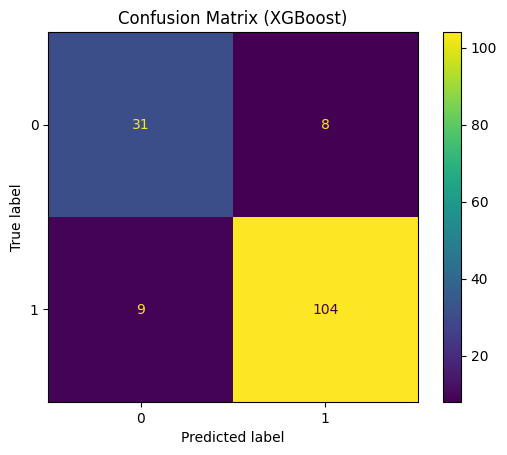

In [104]:
plt.figure()
ConfusionMatrixDisplay.from_estimator(best_model, best_X_test, y_test)
plt.title(f"Confusion Matrix ({best_name})")
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

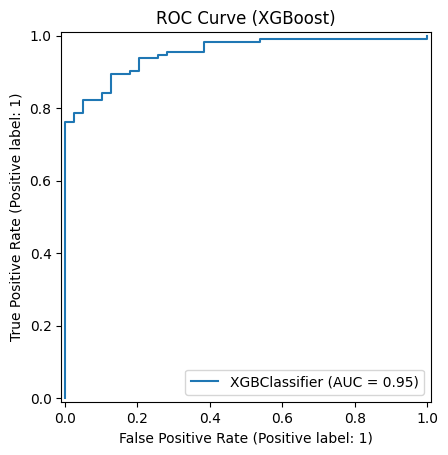

In [105]:
plt.figure()
RocCurveDisplay.from_estimator(best_model, best_X_test, y_test)
plt.title(f"ROC Curve ({best_name})")
plt.savefig("roc_curve.png", dpi=300)
plt.show()

#### Feature Importance


Top 10 Biomarkers:
                        Feature  Importance
58        tqwt_TKEO_mean_dec_12    0.186331
68         tqwt_TKEO_std_dec_13    0.053335
59        tqwt_TKEO_mean_dec_13    0.050741
49      tqwt_entropy_log_dec_16    0.028102
13                std_7th_delta    0.024289
16   std_delta_delta_log_energy    0.020665
43  tqwt_entropy_shannon_dec_16    0.018545
67         tqwt_TKEO_std_dec_12    0.018330
83         tqwt_minValue_dec_14    0.017169
19          std_6th_delta_delta    0.016413


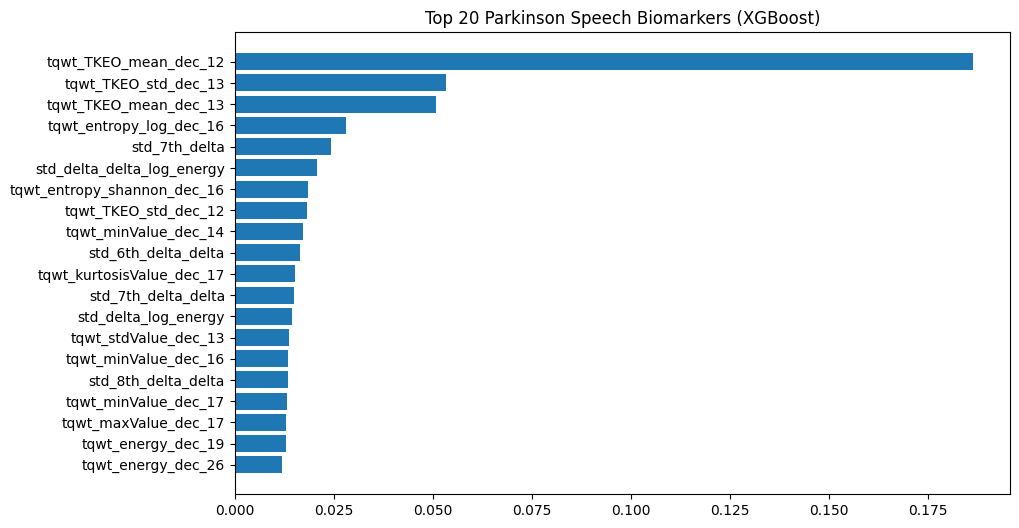

In [106]:
feature_importance = None

if hasattr(best_model, "feature_importances_"):
    importance = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importance = np.abs(best_model.coef_[0])
else:
    importance = None

if importance is not None:
    feature_importance = pd.DataFrame({
        "Feature": selected_features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    print("\nTop 10 Biomarkers:")
    print(feature_importance.head(10))

    top_features = feature_importance.head(20)

    plt.figure(figsize=(10,6))
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Top 20 Parkinson Speech Biomarkers ({best_name})")
    plt.show()


Generating SHAP explanations...


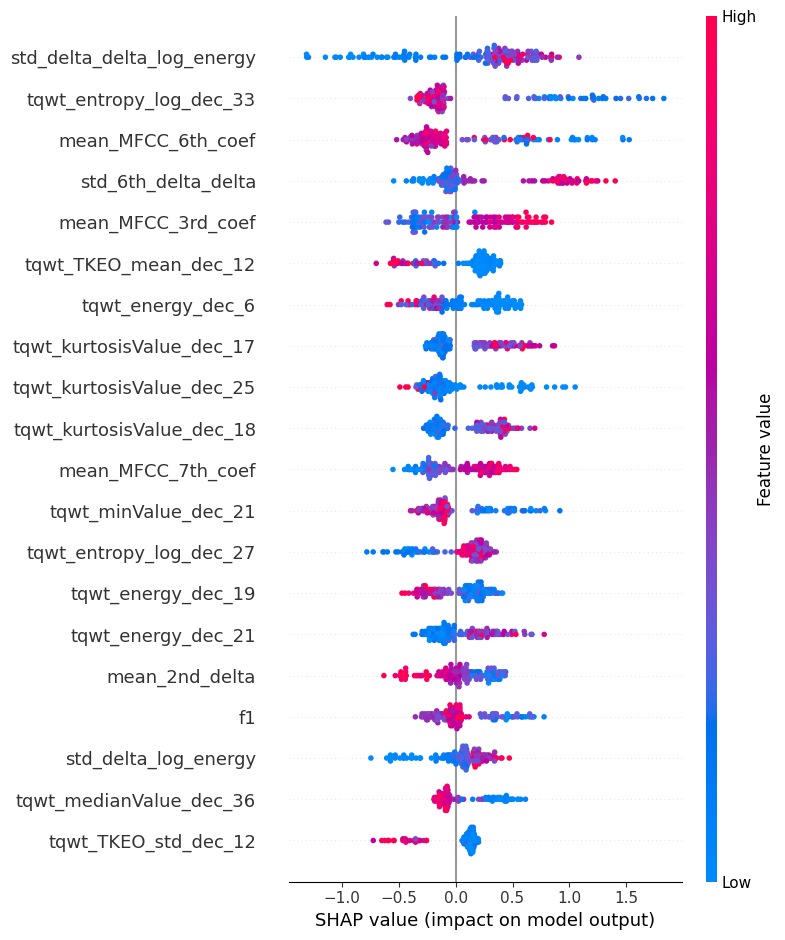

In [107]:
#SHAP
if best_name in ["XGBoost", "Random Forest", "Gradient Boosting", "Decision Tree"]:

    print("\nGenerating SHAP explanations...")

    X_test_df = pd.DataFrame(best_X_test, columns=selected_features)

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_df)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    shap.summary_plot(shap_values, X_test_df)


Calculating Learning Curve...


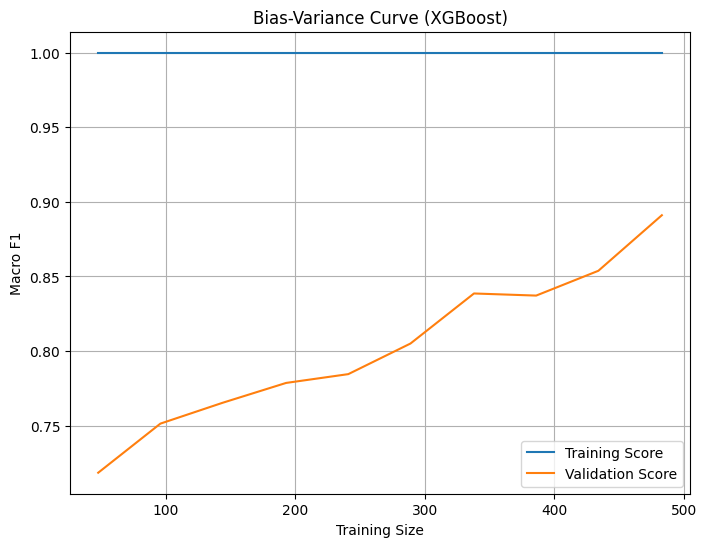

In [108]:
#LEARNING CURVE
print("\nCalculating Learning Curve...")

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', best_model)
])

train_sizes, train_scores, val_scores = learning_curve(
    pipeline,
    best_X_train_base,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro", # Matching our new target metric
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Macro F1")
plt.title(f"Bias-Variance Curve ({best_name})")
plt.legend()
plt.grid(True)
plt.show()

#### Save the Model

In [111]:
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/model.pkl")
joblib.dump(selector, "models/selector.pkl")
joblib.dump(selected_features, "models/features.pkl")
if best_name in distance_models:
    joblib.dump(scaler, "models/scaler.pkl")
metadata = {
    "model": best_name,
    "macro_f1": float(best_score),
    "roc_auc": float(best_roc_auc),
    "num_features": len(selected_features)
}
joblib.dump(metadata, "models/metadata.pkl")
print("\nModel saved successfully!")
print(metadata)


Model saved successfully!
{'model': 'XGBoost', 'macro_f1': 0.8473214285714286, 'roc_auc': 0.9457680962105741, 'num_features': 100}
